# Avaliacao da qualidade dos chunks

Este notebook avalia os chunks gerados em `data/processed/chunks/chunks.jsonl`.

Objetivos:

- medir distribuicao de tamanho;
- validar metadados obrigatorios;
- detectar chunks vazios, muito curtos, muito longos ou com ruido;
- encontrar duplicatas exatas e quase duplicatas simples;
- gerar amostras para revisao manual;
- salvar relatorios em `avaliacao/outputs/`.


In [1]:
from pathlib import Path
import json
import re
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_colwidth", 180)
pd.set_option("display.max_rows", 100)

def find_project_root(start: Path) -> Path:
    start = start.resolve()
    candidates = [start, *start.parents]
    for candidate in candidates:
        chunks_path = candidate / "data" / "processed" / "chunks" / "chunks.jsonl"
        if chunks_path.exists():
            return candidate
    raise FileNotFoundError("Nao encontrei data/processed/chunks/chunks.jsonl a partir do diretorio atual.")

ROOT = find_project_root(Path.cwd())
CHUNKS_PATH = ROOT / "data" / "processed" / "chunks" / "chunks.jsonl"
OUTPUT_DIR = ROOT / "avaliacao" / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CHUNKS_PATH

PosixPath('/home/joaocrm/projects/norta-llm-hoi4-commander/data/processed/chunks/chunks.jsonl')

## 1. Carregamento dos chunks

In [2]:
def load_jsonl(path: Path) -> pd.DataFrame:
    rows = []
    with path.open("r", encoding="utf-8") as f:
        for line_number, line in enumerate(f, start=1):
            line = line.strip()
            if not line:
                continue
            try:
                item = json.loads(line)
            except json.JSONDecodeError as exc:
                raise ValueError(f"JSON invalido em {path}:{line_number}: {exc}") from exc
            item["_line_number"] = line_number
            rows.append(item)
    return pd.DataFrame(rows)

df = load_jsonl(CHUNKS_PATH)
df.shape

(206687, 16)

In [3]:
df.head(3)

,chunk_id,page_id,revision_id,title,display_title,url,source_path,chunk_index,section_index,section_chunk_index,section_path,section_depth,char_count,word_count,text,_line_number
0,patch-1-16-0001,13683,79703,Patch 1.16,Patch 1.16,https://hoi4.paradoxwikis.com/1.16,data/interim/hoi4_wiki/pages/00001-patch-1-16.md,1,1,1,[Graveyard of Empires],1,309,50,## Graveyard of Empires * Added focus tree for Iran * Added focus tree for Iraq * Added focus tree for Afghanistan * Expanded focus tree for the British Raj * Added numerous 3D...,1
1,patch-1-16-0002,13683,79703,Patch 1.16,Patch 1.16,https://hoi4.paradoxwikis.com/1.16,data/interim/hoi4_wiki/pages/00001-patch-1-16.md,2,2,1,[Gameplay],1,499,83,## Gameplay * British Burma now exists from game start as a British subject * Mandatory Palestine now exists from game start as a British subject * Jordan now exists from game ...,2
2,patch-1-16-0003,13683,79703,Patch 1.16,Patch 1.16,https://hoi4.paradoxwikis.com/1.16,data/interim/hoi4_wiki/pages/00001-patch-1-16.md,3,3,1,[Balance],1,372,60,## Balance * Siam now joins the Co-Prosperity sphere on historical * Added a port in Phuket * Added a supply hub in Hat Yai * Siam starts with army of Siam spirit * Extra share...,3


## 2. Normalizacao auxiliar

As metricas abaixo nao substituem avaliacao humana, mas ajudam a encontrar problemas rapidamente.

In [4]:
def normalize_text(text: object) -> str:
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r"\s+", " ", text).strip()
    return text

def simple_token_count(text: object) -> int:
    if not isinstance(text, str):
        return 0
    return len(re.findall(r"\b\w+\b", text))

def text_preview(text: object, limit: int = 350) -> str:
    text = "" if not isinstance(text, str) else re.sub(r"\s+", " ", text).strip()
    return text if len(text) <= limit else text[:limit] + "..."

df["text"] = df.get("text", "").fillna("")
df["computed_char_count"] = df["text"].str.len()
df["computed_word_count"] = df["text"].map(simple_token_count)
df["normalized_text"] = df["text"].map(normalize_text)
df["preview"] = df["text"].map(text_preview)

df[["chunk_id", "title", "section_path", "computed_char_count", "computed_word_count", "preview"]].head(10)

,chunk_id,title,section_path,computed_char_count,computed_word_count,preview
0,patch-1-16-0001,Patch 1.16,[Graveyard of Empires],309,50,## Graveyard of Empires * Added focus tree for Iran * Added focus tree for Iraq * Added focus tree for Afghanistan * Expanded focus tree for the British Raj * Added numerous 3D...
1,patch-1-16-0002,Patch 1.16,[Gameplay],499,83,## Gameplay * British Burma now exists from game start as a British subject * Mandatory Palestine now exists from game start as a British subject * Jordan now exists from game ...
2,patch-1-16-0003,Patch 1.16,[Balance],372,60,## Balance * Siam now joins the Co-Prosperity sphere on historical * Added a port in Phuket * Added a supply hub in Hat Yai * Siam starts with army of Siam spirit * Extra share...
3,patch-1-16-0004,Patch 1.16,[UI],79,11,## UI * Reliability and Torpedo upgrades no longer overlap for torpedo Cruisers
4,patch-1-16-0005,Patch 1.16,[Modding],117,17,"## Modding * has\_artillery\_ratio, has\_cavalry\_ratio and has\_unit\_type triggers now also considers support units"
5,patch-1-16-0006,Patch 1.16,[Bugfix],212,35,"## Bugfix * Fix a CTD when loading games with prepared raids. * Daily army, air and naval XP gain can no longer be negative. * Prevent a rare OOS related to operative mission n..."
6,patch-1-16-0007,Patch 1.16,[Bugfix],718,110,"* Swedish national spirit ""Hungersköld"" is no longer removed too early * The Netherlands can once again Placate the Germans through their Gateway of Europe Decision * Without G..."
7,patch-1-16-0008,Patch 1.16,[Performance],529,73,## Performance * AI is now more performant when upgrading equipment * Weather updates are now more efficiently parallelized * AI plans naval invasion in parallel (drastically r...
8,patch-1-0-x-0001,Patch 1.0.X,[1.0],65,14,"## 1.0 1.0 was the release version, and as such had no changelog."
9,patch-1-0-x-0002,Patch 1.0.X,[1.0.1],85,20,## 1.0.1 1.0.1 is a hotfix which was released on 2016-06-13 with the checksum *f680*.


## 3. Metricas gerais

In [5]:
summary = {
    "total_chunks": int(len(df)),
    "total_pages": int(df["page_id"].nunique()) if "page_id" in df else None,
    "total_titles": int(df["title"].nunique()) if "title" in df else None,
    "empty_text_chunks": int((df["computed_char_count"] == 0).sum()),
    "avg_chars": float(df["computed_char_count"].mean()),
    "median_chars": float(df["computed_char_count"].median()),
    "avg_words": float(df["computed_word_count"].mean()),
    "median_words": float(df["computed_word_count"].median()),
}

pd.Series(summary)

total_chunks         206687.000000
total_pages             739.000000
total_titles            739.000000
empty_text_chunks         0.000000
avg_chars               948.900594
median_chars            904.000000
avg_words               113.520405
median_words            111.000000
dtype: float64

In [26]:
chunks_per_page = (
    df.groupby("page_id")
      .size()
      .describe(percentiles=[0.5, 0.75, 0.90, 0.95, 0.99])
)

print(chunks_per_page)

count      739.000000
mean       279.684709
std       1175.820201
min          1.000000
50%         56.000000
75%        157.500000
90%        426.800000
95%        828.400000
99%       4094.960000
max      18460.000000
dtype: float64


In [27]:
chunks_by_page = (
    df.groupby(["page_id", "title"])
      .size()
      .sort_values(ascending=False)
      .head(30)
)

print(chunks_by_page)

page_id  title                                
957      Achievements                             18460
12669    Formable nations/Europe                  15488
4743     Commander trait                          11792
18674    Releasable countries/Europe               7920
17586    Releasable countries/Africa               7458
18527    Releasable countries/Soviet Union         6996
2434     Effect                                    4887
12670    Formable nations/Asia                     4117
1996     Triggers                                  4059
1061     Land doctrine                             3648
8392     Data structures                           3465
17717    Releasable countries/Asia                 3225
810      Political parties and leaders             2904
327      Ideas                                     2774
19195    Amerindian Nations                        2403
1761     Soviet Union                              2330
329      Construction                              2296
2

In [33]:
duplicate_count = df.duplicated(subset=["text"]).sum()
duplicate_rate = duplicate_count / len(df)

print("Duplicatas:", duplicate_count)
print("Taxa:", duplicate_rate)

import re

def normalize_text(text: str) -> str:
    text = text.lower().strip()
    text = re.sub(r"\s+", " ", text)
    return text

df["normalized_text"] = df["text"].map(normalize_text)

normalized_duplicates = df.duplicated(
    subset=["normalized_text"]
).sum()

print(normalized_duplicates)

def jaccard_similarity(text_a: str, text_b: str) -> float:
    words_a = set(text_a.lower().split())
    words_b = set(text_b.lower().split())

    if not words_a or not words_b:
        return 0.0

    return len(words_a & words_b) / len(words_a | words_b)

similarities = []

for _, group in df.groupby("page_id"):
    group = group.sort_values("chunk_index")

    texts = group["text"].tolist()

    for first, second in zip(texts, texts[1:]):
        similarities.append(
            jaccard_similarity(first, second)
        )

pd.Series(similarities).describe(
    percentiles=[0.5, 0.75, 0.90, 0.95, 0.99]
)

Duplicatas: 159324
Taxa: 0.7708467392724264
159334


count    205948.000000
mean          0.785043
std           0.372200
min           0.000000
50%           1.000000
75%           1.000000
90%           1.000000
95%           1.000000
99%           1.000000
max           1.000000
dtype: float64

In [6]:
df[["computed_char_count", "computed_word_count"]].describe(percentiles=[0.01, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99])

,computed_char_count,computed_word_count
count,206687.000000,206687.000000
mean,948.900594,113.520405
std,646.176982,74.266506
min,1.000000,0.000000
1%,10.000000,1.000000
5%,14.000000,2.000000
10%,105.000000,15.000000
25%,334.000000,45.000000
50%,904.000000,111.000000
75%,1649.000000,181.000000


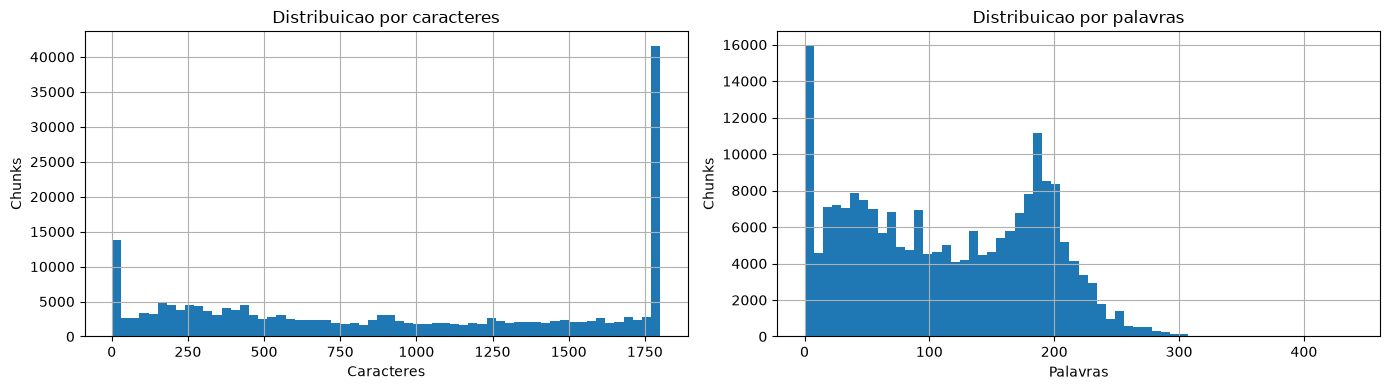

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df["computed_char_count"].hist(bins=60, ax=axes[0])
axes[0].set_title("Distribuicao por caracteres")
axes[0].set_xlabel("Caracteres")
axes[0].set_ylabel("Chunks")

df["computed_word_count"].hist(bins=60, ax=axes[1])
axes[1].set_title("Distribuicao por palavras")
axes[1].set_xlabel("Palavras")
axes[1].set_ylabel("Chunks")

plt.tight_layout()
plt.show()

## 4. Validacao de metadados

Campos ausentes enfraquecem debugging, filtros de recuperacao e citacoes no RAG.

In [8]:
required_columns = [
    "chunk_id",
    "page_id",
    "revision_id",
    "title",
    "display_title",
    "url",
    "source_path",
    "chunk_index",
    "section_index",
    "section_chunk_index",
    "section_path",
    "section_depth",
    "text",
]

metadata_report = []
for column in required_columns:
    if column not in df.columns:
        metadata_report.append({"column": column, "exists": False, "missing_or_empty": len(df), "missing_pct": 100.0})
        continue
    missing = df[column].isna() | (df[column].astype(str).str.len() == 0)
    metadata_report.append({
        "column": column,
        "exists": True,
        "missing_or_empty": int(missing.sum()),
        "missing_pct": float(missing.mean() * 100),
    })

metadata_df = pd.DataFrame(metadata_report)
metadata_df

,column,exists,missing_or_empty,missing_pct
0,chunk_id,True,0,0.0
1,page_id,True,0,0.0
2,revision_id,True,0,0.0
3,title,True,0,0.0
4,display_title,True,0,0.0
5,url,True,0,0.0
6,source_path,True,0,0.0
7,chunk_index,True,0,0.0
8,section_index,True,0,0.0
9,section_chunk_index,True,0,0.0


In [9]:
if "chunk_id" in df:
    duplicated_ids = df[df["chunk_id"].duplicated(keep=False)].sort_values("chunk_id")
else:
    duplicated_ids = pd.DataFrame()

duplicated_ids[["chunk_id", "title", "section_path", "preview"]].head(30) if not duplicated_ids.empty else "Sem chunk_id duplicado."

,chunk_id,title,section_path,preview
1387,achievement-modding-0001,Achievement modding,[File structure],## File structure ``` custom_achievements/ common/achievements/ custom_achievements_achievements.txt gfx/achievements/ custom_achievement_test.dds custom_achievement_test_grey....
42653,achievement-modding-0001,Achievement modding,[File structure],## File structure ``` custom_achievements/ common/achievements/ custom_achievements_achievements.txt gfx/achievements/ custom_achievement_test.dds custom_achievement_test_grey....
1388,achievement-modding-0002,Achievement modding,[Coding syntax],## Coding syntax * **unique\_id** - This is mandatory and custom to your mod. It references the name of the cloudsavefile that will store the achievements. * **custom\_achievem...
42654,achievement-modding-0002,Achievement modding,[Coding syntax],## Coding syntax * **unique\_id** - This is mandatory and custom to your mod. It references the name of the cloudsavefile that will store the achievements. * **custom\_achievem...
1389,achievement-modding-0003,Achievement modding,[Coding syntax],"+ Some common triggers not used in the code example are tag checks (with either [tag](/Triggers#tag ""Triggers"") or [original\_tag](/Triggers#original_tag ""Triggers"")) or ironma..."
42655,achievement-modding-0003,Achievement modding,[Coding syntax],"+ Some common triggers not used in the code example are tag checks (with either [tag](/Triggers#tag ""Triggers"") or [original\_tag](/Triggers#original_tag ""Triggers"")) or ironma..."
1390,achievement-modding-0004,Achievement modding,[Coding syntax],``` unique_id = custom_achievements_123456 custom_achievement = { possible = {
42656,achievement-modding-0004,Achievement modding,[Coding syntax],``` unique_id = custom_achievements_123456 custom_achievement = { possible = {
1391,achievement-modding-0005,Achievement modding,[classic triggers used in all vanilla achievements],# classic triggers used in all vanilla achievements difficulty > 1 has_start_date < 1936.01.02 has_any_custom_difficulty_setting = no game_rules_allow_achievements = yes } happ...
42657,achievement-modding-0005,Achievement modding,[classic triggers used in all vanilla achievements],# classic triggers used in all vanilla achievements difficulty > 1 has_start_date < 1936.01.02 has_any_custom_difficulty_setting = no game_rules_allow_achievements = yes } happ...


## 5. Chunks suspeitos por tamanho

Ajuste os limites abaixo conforme o tamanho de contexto do seu modelo de embedding e o comportamento do seu chunker.

In [10]:
MIN_WORDS = 30
MAX_WORDS = 350

too_short = df[df["computed_word_count"] < MIN_WORDS].sort_values("computed_word_count")
too_long = df[df["computed_word_count"] > MAX_WORDS].sort_values("computed_word_count", ascending=False)

print(f"Chunks muito curtos (< {MIN_WORDS} palavras): {len(too_short)}")
print(f"Chunks muito longos (> {MAX_WORDS} palavras): {len(too_long)}")

Chunks muito curtos (< 30 palavras): 34831
Chunks muito longos (> 350 palavras): 66


In [11]:
too_short[["chunk_id", "title", "section_path", "computed_word_count", "preview"]].head(30)

,chunk_id,title,section_path,computed_word_count,preview
71519,german-reich-0158,German Reich,"[Staff and designers, Companies, Organizations]",0,| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | ...
197277,formable-nations-europe-0026,Formable nations/Europe,"[Austria-Hungary, [Decision generic decision.png](/File:Decision_generic_decision.png)Re-Form the Austro-Hungarian Empire]",0,| | |
196925,formable-nations-europe-0026,Formable nations/Europe,"[Austria-Hungary, [Decision generic decision.png](/File:Decision_generic_decision.png)Re-Form the Austro-Hungarian Empire]",0,| | |
196469,commander-trait-0025,Commander trait,"[General and field marshal, Earned traits]",0,|
196415,government-0020,Government,[Command Power],0,|
196558,formable-nations-europe-0026,Formable nations/Europe,"[Austria-Hungary, [Decision generic decision.png](/File:Decision_generic_decision.png)Re-Form the Austro-Hungarian Empire]",0,| | |
5611,formable-nations-asia-0026,Formable nations/Asia,"[Akhand Bharat, [Decision generic decision.png](/File:Decision_generic_decision.png)Claim Sri Lankan States]",0,| | |
195959,amerindian-nations-0045,Amerindian Nations,[Indigenista Mexico],0,|
195955,amerindian-nations-0041,Amerindian Nations,[Inca Empire],0,|
195946,amerindian-nations-0032,Amerindian Nations,[Great Pindorama],0,|


In [12]:
too_long[["chunk_id", "title", "section_path", "computed_word_count", "preview"]].head(30)

,chunk_id,title,section_path,computed_word_count,preview
47659,defines-0419,Defines,[NGraphics],439,"| | | INTEL\_NETWORK\_VALID\_TARGET\_STRIPE\_COLOR | { 0.1, 0.5, 0.8, 1.0 } | Color of the stripes of painted over a valid state to start building an intel network | | | INTEL\..."
48103,defines-0419,Defines,[NGraphics],439,"| | | INTEL\_NETWORK\_VALID\_TARGET\_STRIPE\_COLOR | { 0.1, 0.5, 0.8, 1.0 } | Color of the stripes of painted over a valid state to start building an intel network | | | INTEL\..."
105363,list-of-1936-start-legacy-deployed-destroyers-0009,List of 1936 start legacy deployed destroyers,[],435,r\_1 | V/W | HMS Worcester | 30.3 kn | 1500 km | 18.0 | 9.0 | 2.5 | 19.8 | 4.5 | 0 | 0 | 0 | 0 | | ENG | destroyer\_1 | V/W | HMS Wren | 30.3 kn | 1500 km | 18.0 | 9.0 | 2.5 | ...
105364,list-of-1936-start-legacy-deployed-destroyers-0010,List of 1936 start legacy deployed destroyers,[],433,1 | 2 | 1 | 3 | | ENG | destroyer\_1b | A/B/C/D | HMS Blanche | 34.0 kn | 1710 km | 18.9 | 9.7 | 2.6 | 22.0 | 5.4 | 1 | 2 | 1 | 3 | | ENG | destroyer\_1b | A/B/C/D | HMS Boadic...
105365,list-of-1936-start-legacy-deployed-destroyers-0011,List of 1936 start legacy deployed destroyers,[],432,ght | 34.0 kn | 1710 km | 18.9 | 9.7 | 2.6 | 22.0 | 5.4 | 1 | 2 | 1 | 3 | | ENG | destroyer\_1b | A/B/C/D | HMS Dainty | 34.0 kn | 1710 km | 18.9 | 9.7 | 2.6 | 22.0 | 5.4 | 1 |...
105359,list-of-1936-start-legacy-deployed-destroyers-0005,List of 1936 start legacy deployed destroyers,[],424,0 km | 18.0 | 9.0 | 2.5 | 19.8 | 4.5 | 0 | 0 | 0 | 0 | | ENG | destroyer\_1 | V/W | HMS Sabre | 30.3 kn | 1500 km | 18.0 | 9.0 | 2.5 | 19.8 | 4.5 | 0 | 0 | 0 | 0 | | ENG | dest...
105360,list-of-1936-start-legacy-deployed-destroyers-0006,List of 1936 start legacy deployed destroyers,[],423,19.8 | 4.5 | 0 | 0 | 0 | 0 | | ENG | destroyer\_1 | V/W | HMS Vanessa | 30.3 kn | 1500 km | 18.0 | 9.0 | 2.5 | 19.8 | 4.5 | 0 | 0 | 0 | 0 | | ENG | destroyer\_1 | V/W | HMS Van...
105361,list-of-1936-start-legacy-deployed-destroyers-0007,List of 1936 start legacy deployed destroyers,[],419,0 | | ENG | destroyer\_1 | V/W | HMS Vimy | 30.3 kn | 1500 km | 18.0 | 9.0 | 2.5 | 19.8 | 4.5 | 0 | 0 | 0 | 0 | | ENG | destroyer\_1 | V/W | HMS Viscount | 30.3 kn | 1500 km | ...
105362,list-of-1936-start-legacy-deployed-destroyers-0008,List of 1936 start legacy deployed destroyers,[],418,troyer\_1 | V/W | HMS Whirlwind | 30.3 kn | 1500 km | 18.0 | 9.0 | 2.5 | 19.8 | 4.5 | 0 | 0 | 0 | 0 | | ENG | destroyer\_1 | V/W | HMS Whitehall | 30.3 kn | 1500 km | 18.0 | 9....
105370,list-of-1936-start-legacy-deployed-destroyers-0016,List of 1936 start legacy deployed destroyers,[],406,23 | Falke | 31.9 kn | 1500 km | 18.0 | 9.0 | 2.5 | 20.0 | 5.0 | 0 | 0 | 0 | 0 | | GER | destroyer\_1 | Type 23 | Greif | 31.9 kn | 1500 km | 18.0 | 9.0 | 2.5 | 20.0 | 5.0 | 0 ...


## 6. Ruido comum de wiki

A lista abaixo procura boilerplate e residuos frequentes. Adicione padroes conforme encontrar falsos negativos.

In [13]:
noise_patterns = {
    "navigation": r"navigation menu|personal tools|namespaces|views|search",
    "wiki_footer": r"retrieved from|category:|categories:|this page was last edited",
    "edit_links": r"\[edit\]|edit source|view history",
    "template_residue": r"\{\{|\}\}|\[\[|\]\]",
    "html_residue": r"<[^>]+>",
    "excessive_whitespace": r"\s{4,}",
}

noise_report = []
for name, pattern in noise_patterns.items():
    mask = df["text"].str.contains(pattern, case=False, regex=True, na=False)
    noise_report.append({"pattern": name, "chunks": int(mask.sum()), "pct": float(mask.mean() * 100)})

noise_df = pd.DataFrame(noise_report).sort_values("chunks", ascending=False)
noise_df

,pattern,chunks,pct
3,template_residue,37434,18.111444
0,navigation,14333,6.934640
4,html_residue,9085,4.395535
1,wiki_footer,2058,0.995708
2,edit_links,0,0.000000
5,excessive_whitespace,0,0.000000


In [14]:
noise_mask = pd.Series(False, index=df.index)
for pattern in noise_patterns.values():
    noise_mask |= df["text"].str.contains(pattern, case=False, regex=True, na=False)

noisy_chunks = df[noise_mask]
noisy_chunks[["chunk_id", "title", "section_path", "computed_word_count", "preview"]].head(50)

,chunk_id,title,section_path,computed_word_count,preview
18,patch-1-14-0003,Patch 1.14,[Balance],158,## Balance * reduced the number of super heavy tank destroyers needed for support battalion to 20 * reduced IC cost of jet engines considerably * German focus 'Treaty with the ...
20,patch-1-14-0005,Patch 1.14,[AI],181,## AI * Fixed bugs in how AI selects research * A bunch of bugfixes and improvements to how AI calculates research weights * AI will now pick more appropriate military spirits....
21,patch-1-14-0006,Patch 1.14,[Modding],160,"## Modding * Added AI strategy research\_weight\_factor * Added variable values for deployed\_army\_manpower\_k, deployed\_navy\_manpower\_k, deployed\_airforce\_manpower\_k, a..."
30,patch-1-15-0002,Patch 1.15,[Feature],100,"## Feature * Research Tab was enriched with Scientists, Experimental Facilities and Special Projects. * Added 15 new Special Projects * Added 2 Special Projects to the No Step ..."
38,patch-1-15-0010,Patch 1.15,[Balance],105,* Cavalry now gets +5% Breakthrough in Infantry Offensive Doctrine (Grand Battleplan Infilitration Path) and Cavalry Recon bonus from Infiltration Assault (Grand Battleplan Inf...
49,patch-1-15-0021,Patch 1.15,[Modding],250,## Modding * Fix trigger all\_enemy\_country trigger to evaluate all countries and not just any * Added variable divisional\_commander\_xp to set divisional officer experience ...
58,patch-1-13-0001,Patch 1.13,[Arms Against Tyranny],59,## Arms Against Tyranny * Added ahistorical Finnish focus tree paths * Added full Norwegian focus tree * Added full Swedish focus tree * Added full Danish focus tree * Added a ...
61,patch-1-13-0004,Patch 1.13,[Balance],113,"## Balance * Reduced Germanys steel * increased Swedens steel and tungsten from 220 Steel, 67 tungsten, 42 chromium to 260 steel, 123 tungsten and 63 chromium (closed trade res..."
63,patch-1-13-0006,Patch 1.13,[Balance],295,"* Most tank chassis' now grant 10-20% more armor * Super heavy tanks now cost more overall, but require 20 per support company * The winter war should now start according to hi..."
66,patch-1-13-0009,Patch 1.13,[Balance],216,* added 5% for local resources from compliance gain (from 0.6 to 0.65) * People's Army focus now grants a battalion modifier from military police to horseback cavalry suppressi...


## 7. Duplicatas e quase duplicatas simples

In [15]:
exact_duplicates = df[df["normalized_text"].duplicated(keep=False) & (df["normalized_text"].str.len() > 0)].copy()
exact_duplicates = exact_duplicates.sort_values(["normalized_text", "title", "chunk_id"])

print(f"Chunks com texto exatamente duplicado apos normalizacao: {len(exact_duplicates)}")
exact_duplicates[["chunk_id", "title", "section_path", "computed_word_count", "preview"]].head(50)

Chunks com texto exatamente duplicado apos normalizacao: 177437


,chunk_id,title,section_path,computed_word_count,preview
3565,releasable-countries-asia-0050,Releasable countries/Asia,[Pakistan],199,""") * [Flag of India](/India ""India"") [India](/India ""India"") has become [free](/Puppet#Autonomy_levels ""free"")[Free](/Puppet#Autonomy_levels ""Puppet"") via the [autonomy](/Auton..."
5138,releasable-countries-asia-0050,Releasable countries/Asia,[Pakistan],199,""") * [Flag of India](/India ""India"") [India](/India ""India"") has become [free](/Puppet#Autonomy_levels ""free"")[Free](/Puppet#Autonomy_levels ""Puppet"") via the [autonomy](/Auton..."
10674,releasable-countries-asia-0050,Releasable countries/Asia,[Pakistan],199,""") * [Flag of India](/India ""India"") [India](/India ""India"") has become [free](/Puppet#Autonomy_levels ""free"")[Free](/Puppet#Autonomy_levels ""Puppet"") via the [autonomy](/Auton..."
13148,releasable-countries-asia-0050,Releasable countries/Asia,[Pakistan],199,""") * [Flag of India](/India ""India"") [India](/India ""India"") has become [free](/Puppet#Autonomy_levels ""free"")[Free](/Puppet#Autonomy_levels ""Puppet"") via the [autonomy](/Auton..."
23118,releasable-countries-asia-0050,Releasable countries/Asia,[Pakistan],199,""") * [Flag of India](/India ""India"") [India](/India ""India"") has become [free](/Puppet#Autonomy_levels ""free"")[Free](/Puppet#Autonomy_levels ""Puppet"") via the [autonomy](/Auton..."
23193,releasable-countries-asia-0050,Releasable countries/Asia,[Pakistan],199,""") * [Flag of India](/India ""India"") [India](/India ""India"") has become [free](/Puppet#Autonomy_levels ""free"")[Free](/Puppet#Autonomy_levels ""Puppet"") via the [autonomy](/Auton..."
26125,releasable-countries-asia-0050,Releasable countries/Asia,[Pakistan],199,""") * [Flag of India](/India ""India"") [India](/India ""India"") has become [free](/Puppet#Autonomy_levels ""free"")[Free](/Puppet#Autonomy_levels ""Puppet"") via the [autonomy](/Auton..."
29457,releasable-countries-asia-0050,Releasable countries/Asia,[Pakistan],199,""") * [Flag of India](/India ""India"") [India](/India ""India"") has become [free](/Puppet#Autonomy_levels ""free"")[Free](/Puppet#Autonomy_levels ""Puppet"") via the [autonomy](/Auton..."
29827,releasable-countries-asia-0050,Releasable countries/Asia,[Pakistan],199,""") * [Flag of India](/India ""India"") [India](/India ""India"") has become [free](/Puppet#Autonomy_levels ""free"")[Free](/Puppet#Autonomy_levels ""Puppet"") via the [autonomy](/Auton..."
48339,releasable-countries-asia-0050,Releasable countries/Asia,[Pakistan],199,""") * [Flag of India](/India ""India"") [India](/India ""India"") has become [free](/Puppet#Autonomy_levels ""free"")[Free](/Puppet#Autonomy_levels ""Puppet"") via the [autonomy](/Auton..."


In [16]:
def token_set_signature(text: str, max_tokens: int = 80) -> str:
    tokens = re.findall(r"\b[a-z0-9][a-z0-9_-]{2,}\b", normalize_text(text))
    counts = Counter(tokens)
    common = [token for token, _count in counts.most_common(max_tokens)]
    return " ".join(sorted(common))

df["token_signature"] = df["text"].map(token_set_signature)
near_duplicate_groups = (
    df[df["token_signature"].str.len() > 0]
    .groupby("token_signature")
    .size()
    .reset_index(name="count")
    .query("count > 1")
    .sort_values("count", ascending=False)
)

near_duplicate_groups.head(20)

,token_signature,count
45804,decisions,6213
45699,country faction government government_type ideology leader name non-aligned none party political popularity ruling type,805
45685,country democratic faction government government_type ideology leader name none party political popularity ruling type,597
42816,article austro-hungarian austro-hungarian_joint_national_focus_tree_branches branches focus joint main national tree,594
41020,and guides strategies,367
46517,technology,244
46454,politics,228
45948,economy,213
40971,and designers staff,212
46374,military,206


## 8. Coerencia de limites do chunk

Essas heuristicas ajudam a identificar chunks que podem estar cortando conteudo em pontos ruins.

In [17]:
def starts_with_context_marker(text: str) -> bool:
    return bool(re.match(r"^\s*(#{1,6}\s+|[-*]\s+|\d+[.)]\s+)", text or ""))

def ends_cleanly(text: str) -> bool:
    text = (text or "").rstrip()
    if not text:
        return False
    return text[-1] in ".!?):;]" or bool(re.search(r"\w$", text))

boundary_df = df.assign(
    starts_with_marker=df["text"].map(starts_with_context_marker),
    ends_cleanly=df["text"].map(ends_cleanly),
)

pd.DataFrame({
    "starts_with_header_or_list_pct": [boundary_df["starts_with_marker"].mean() * 100],
    "ends_cleanly_pct": [boundary_df["ends_cleanly"].mean() * 100],
})

,starts_with_header_or_list_pct,ends_cleanly_pct
0,35.712938,81.499562


In [18]:
boundary_df[~boundary_df["ends_cleanly"]][["chunk_id", "title", "section_path", "preview"]].head(30)

,chunk_id,title,section_path,preview
230,patch-1-19-0008,Patch 1.19,[Balance],* Continuous Offensives: All armour additionally gains +10% breakthrough. * Self-Sufficient Battalion: Armored signal battalion\_mult on tank destroyers nerfed: AP attack reduc...
333,patch-1-3-0020,Patch 1.3,[Modding],etc etc. * Added add\_ideas command to console * Added on\_release\_as\_puppet on\_release\_as\_free triggered from the manage occupied territories menu * Added 'set\_cosmetic\...
361,30-minutes-of-hel-0014,30 Minutes of Hel,[Method 3],"""Cheese your fighter."") • [Chilean Empire](/Chilean_Empire ""Chilean Empire"") • [Crusader Kings 2](/Crusader_Kings_2 ""Crusader Kings 2"") • [Crusader Kings IV](/Crusader_Kings_IV..."
426,ai-focuses-0019,AI focuses,"[Modding, Research weights]",### Research weights The /Hearts of Iron IV/common/ai\_focuses files controls how much the AI focuses affect which kinds of research and national focuses. Each focus name can b...
429,ai-focuses-0022,AI focuses,"[Modding, Historical focuses]","""Faction modding"") • [Ideas](/Idea_modding ""Idea modding"") • [Ideologies](/Ideology_modding ""Ideology modding"") • [Military industrial organizations](/Military_industrial_organ..."
439,ai-modding-0009,AI modding,"[If the country is Germany, set the value to 0,]","# If the country is Germany, set the value to 0,"
442,ai-modding-0012,AI modding,"[causing an early end of the evaluation., AI strategies]","If an AI strategy modifies the chance for AI to pick a diplomatic option with the player, it will be seen as `COUNTRY has strategic reasons to be ...` to the player when hoveri..."
448,ai-modding-0018,AI modding,"[causing an early end of the evaluation., AI strategies, Arguments]","It does not have a default scope, so scoping into a country is required. An example of a reversed AI strategy is the following: ``` BHR_support_neutrals = { allowed = { NOT = {..."
505,ai-modding-0075,AI modding,"[causing an early end of the evaluation., AI strategies, Types]","| value = 50 means 50% increase, -30 means 30% decrease, etc. |"
507,ai-modding-0077,AI modding,"[causing an early end of the evaluation., AI areas]","If there are multiple defined, the province has to be in *any* of them. An example of an AI area is the following: ``` my_ai_area = { continents = { europe africa } strategic_r..."


## 9. Distribuicao por pagina e secao

In [19]:
page_stats = (
    df.groupby(["page_id", "title"], dropna=False)
    .agg(
        chunks=("chunk_id", "count"),
        words_total=("computed_word_count", "sum"),
        words_median=("computed_word_count", "median"),
    )
    .reset_index()
    .sort_values("chunks", ascending=False)
)

page_stats.head(30)

,page_id,title,chunks,words_total,words_median
37,957,Achievements,18460,2534792,145.0
558,12669,Formable nations/Europe,15488,1591172,78.0
324,4743,Commander trait,11792,1299264,102.5
693,18674,Releasable countries/Europe,7920,728772,93.5
660,17586,Releasable countries/Africa,7458,648450,93.0
682,18527,Releasable countries/Soviet Union,6996,626010,103.5
144,2434,Effect,4887,323346,48.0
559,12670,Formable nations/Asia,4117,403190,78.0
106,1996,Triggers,4059,254441,46.0
55,1061,Land doctrine,3648,468800,143.0


In [20]:
section_depth_stats = (
    df.groupby("section_depth", dropna=False)
    .agg(chunks=("chunk_id", "count"), median_words=("computed_word_count", "median"))
    .reset_index()
    .sort_values("section_depth")
)

section_depth_stats

,section_depth,chunks,median_words
0,0,2437,195.0
1,1,86738,112.0
2,2,92543,92.0
3,3,20594,159.0
4,4,3940,121.0
5,5,435,132.0


## 10. Amostra para revisao manual

Use esta amostra para pontuar qualidade humana. Sugestao de escala:

- `0`: inutil, ruido ou texto quebrado;
- `1`: parcialmente legivel, mas pouco util;
- `2`: bom, com contexto suficiente;
- `3`: excelente, autocontido e util para responder perguntas.

Preencha depois as colunas `score_autocontido`, `score_ruido`, `score_granularidade`, `score_utilidade` no CSV exportado.

In [21]:
SAMPLE_SIZE = min(100, len(df))
RANDOM_SEED = 42

review_sample = (
    df.sample(SAMPLE_SIZE, random_state=RANDOM_SEED)
    [["chunk_id", "title", "section_path", "url", "computed_word_count", "preview", "text"]]
    .copy()
)

for column in ["score_autocontido", "score_ruido", "score_granularidade", "score_utilidade", "observacoes"]:
    review_sample[column] = ""

review_path = OUTPUT_DIR / "amostra_revisao_chunks.csv"
review_sample.to_csv(review_path, index=False)

review_path

PosixPath('/home/joaocrm/projects/norta-llm-hoi4-commander/avaliacao/outputs/amostra_revisao_chunks.csv')

In [22]:
review_sample.head(10)

,chunk_id,title,section_path,url,computed_word_count,preview,text,score_autocontido,score_ruido,score_granularidade,score_utilidade,observacoes
44229,czechoslovakian-events-pfot-0149,Czechoslovakian events PfoT,"[id 1031 - 1040, Germany Protects Hungary]",https://hoi4.paradoxwikis.com/Czechoslovakian_events_PfoT,114,"### Germany Protects Hungary *After noticing the obvious war justifying going on in our country towards [HUN.GetNameDef], [GER.GetAdjective] representatives have made clear tha...","### Germany Protects Hungary *After noticing the obvious war justifying going on in our country towards [HUN.GetNameDef], [GER.GetAdjective] representatives have made clear tha...",,,,,
104174,equipment-0037,Equipment,[Armor equipment],https://hoi4.paradoxwikis.com/Lend_lease,43,"SPG | M. SPG I | 8 | 42 | 1 | | 5 | 3 | 45 | 5 | 65% | 1.8 | 80% | 12 | 2 | 3 | | | | M. Tank I, M. Tank II | | M. SPG II | 9 | 50 | 1.5 | | 6 | 3 | 50 | 0 | 65% | 1.8 | 80% | ...","SPG | M. SPG I | 8 | 42 | 1 | | 5 | 3 | 45 | 5 | 65% | 1.8 | 80% | 12 | 2 | 3 | | | | M. Tank I, M. Tank II | | M. SPG II | 9 | 50 | 1.5 | | 6 | 3 | 50 | 0 | 65% | 1.8 | 80% | ...",,,,,
67022,ideas-0052,Ideas,"[Design companies, Tank designers]",https://hoi4.paradoxwikis.com/Free_Trade,91,"### Tank designers *See also: [List of tank designers](/List_of_tank_designers ""List of tank designers"")* Companies also typically have **+15%** or **+10%** [Armor](/Armor_tech...","### Tank designers *See also: [List of tank designers](/List_of_tank_designers ""List of tank designers"")* Companies also typically have **+15%** or **+10%** [Armor](/Armor_tech...",,,,,
194604,amerindian-nations-0067,Amerindian Nations,[Nahua Nation],https://hoi4.paradoxwikis.com/United_Inuit_States,70,"## Nahua Nation Nahua Nation [![Nahua Nation.png](/images/a/aa/Nahua_Nation.png)](/File:Nahua_Nation.png) --- [Capital](/Capital ""Capital""): San Salvador --- [Government type](...","## Nahua Nation Nahua Nation [![Nahua Nation.png](/images/a/aa/Nahua_Nation.png)](/File:Nahua_Nation.png) --- [Capital](/Capital ""Capital""): San Salvador --- [Government type](...",,,,,
165488,releasable-countries-europe-0017,Releasable countries/Europe,"[Baden-Württemberg, Decisions]",https://hoi4.paradoxwikis.com/Scotland,1,### Decisions,### Decisions,,,,,
58730,releasable-countries-soviet-union-0089,Releasable countries/Soviet Union,[Ukraine],https://hoi4.paradoxwikis.com/Evenkia,47,"## Ukraine Republic of Ukraine --- [Capital](/Capital ""Capital""): Kyiv (Kiev) --- [Government type](/Government_type ""Government type""): Democratic --- [Faction](/Faction ""Fact...","## Ukraine Republic of Ukraine --- [Capital](/Capital ""Capital""): Kyiv (Kiev) --- [Government type](/Government_type ""Government type""): Democratic --- [Faction](/Faction ""Fact...",,,,,
22214,british-national-focus-tree-0338,British national focus tree,"[A Change in Course Branch, Concessions to the Trade Unions Sub-branch]",https://hoi4.paradoxwikis.com/British_Austerity,140,"| United Kingdom: * Requires *one* of the following: + [Soviet Cooperation](/British_national_focus_tree#Soviet_Cooperation ""Soviet Cooperation"")[Soviet Cooperation](/British_n...","| United Kingdom: * Requires *one* of the following: + [Soviet Cooperation](/British_national_focus_tree#Soviet_Cooperation ""Soviet Cooperation"")[Soviet Cooperation](/British_n...",,,,,
161270,achievements-0305,Achievements,"[No Compromise, No Surrender]",https://hoi4.paradoxwikis.com/Romance_of_the_Three_Kingdoms,187,"## No Compromise, No Surrender | Achievement | Starting conditions | Requirements | Notes | [Hearts of Iron IV](/Hearts_of_Iron_IV ""Hearts of Iron IV"") | Ver | DI | | --- | ---...","## No Compromise, No Surrender | Achievement | Starting conditions | Requirements | Notes | [Hearts of Iron IV](/Hearts_of_Iron_IV ""Hearts of Iron IV"") | Ver | DI | | --- | ---...",,,,,
31523,chinese-national-focus-tree-base-game-0037,Chinese national focus tree (base game),[Military Affairs Commission branch]

## 11. Relatorio final

In [23]:
report = {
    **summary,
    "min_words_threshold": MIN_WORDS,
    "max_words_threshold": MAX_WORDS,
    "too_short_chunks": int(len(too_short)),
    "too_long_chunks": int(len(too_long)),
    "metadata_missing": metadata_df.to_dict(orient="records"),
    "noise_report": noise_df.to_dict(orient="records"),
    "exact_duplicate_chunks": int(len(exact_duplicates)),
    "duplicated_chunk_ids": int(len(duplicated_ids)),
}

report_path = OUTPUT_DIR / "relatorio_chunks.json"
with report_path.open("w", encoding="utf-8") as f:
    json.dump(report, f, ensure_ascii=False, indent=2)

metadata_df.to_csv(OUTPUT_DIR / "metadata_report.csv", index=False)
noise_df.to_csv(OUTPUT_DIR / "noise_report.csv", index=False)
too_short[["chunk_id", "title", "section_path", "computed_word_count", "preview"]].to_csv(OUTPUT_DIR / "chunks_muito_curtos.csv", index=False)
too_long[["chunk_id", "title", "section_path", "computed_word_count", "preview"]].to_csv(OUTPUT_DIR / "chunks_muito_longos.csv", index=False)
page_stats.to_csv(OUTPUT_DIR / "page_stats.csv", index=False)

report_path

PosixPath('/home/joaocrm/projects/norta-llm-hoi4-commander/avaliacao/outputs/relatorio_chunks.json')

## Como interpretar

Sinais de que o processo de chunking precisa melhorar:

- muitos chunks abaixo de `MIN_WORDS`, pois tendem a nao carregar contexto suficiente;
- muitos chunks acima de `MAX_WORDS`, pois podem misturar assuntos e piorar recuperacao;
- metadados ausentes, especialmente `title`, `section_path`, `url` e `chunk_id`;
- duplicatas exatas ou quase duplicatas, que poluem o top-k do RAG;
- ruido de wiki nos textos;
- amostra manual com media abaixo de `2` em autocontencao ou utilidade.
